##Cargando los datos

In [1]:
import pandas as pd

df = pd.read_csv("telecomx_churn_limpio.csv")
df.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,cargo_mensual,cargo_total,cargo_diario,total_servicios
0,0002-orfbo,0.0,female,0,yes,yes,9,yes,no,dsl,...,1,1,0,one year,yes,mailed check,65.6,593.30,2.186667,3
1,0003-mknfe,0.0,male,0,no,no,9,yes,yes,dsl,...,0,0,1,month-to-month,no,mailed check,59.9,542.40,1.996667,1
2,0004-tlhlj,1.0,male,0,no,no,4,yes,no,fiber optic,...,0,0,0,month-to-month,yes,electronic check,73.9,280.85,2.463333,1
3,0011-igkff,1.0,male,1,yes,no,13,yes,no,fiber optic,...,0,1,1,month-to-month,yes,electronic check,98.0,1237.85,3.266667,4
4,0013-exchz,1.0,female,1,yes,no,3,yes,no,fiber optic,...,1,1,0,month-to-month,yes,mailed check,83.9,267.40,2.796667,2


In [2]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7267 non-null   object 
 1   churn             7043 non-null   float64
 2   gender            7267 non-null   object 
 3   seniorcitizen     7267 non-null   int64  
 4   partner           7267 non-null   object 
 5   dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   phoneservice      7267 non-null   object 
 8   multiplelines     7267 non-null   object 
 9   internetservice   7267 non-null   object 
 10  onlinesecurity    7267 non-null   int64  
 11  onlinebackup      7267 non-null   int64  
 12  deviceprotection  7267 non-null   int64  
 13  techsupport       7267 non-null   int64  
 14  streamingtv       7267 non-null   int64  
 15  streamingmovies   7267 non-null   int64  
 16  contract          7267 non-null   object 


,0
customerid,0
churn,224
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Eliminación de columnas irrelevantes

Se eliminó la columna customerid porque actúa únicamente como identificador único de cada cliente.
Este tipo de variables no aporta información útil para los modelos predictivos y puede introducir ruido en el entrenamiento.

In [5]:
df = df.drop(columns=['customerid'])



In [6]:
df.head()


,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,cargo_mensual,cargo_total,cargo_diario,total_servicios
0,0.0,female,0,yes,yes,9,yes,no,dsl,0,...,1,1,0,one year,yes,mailed check,65.6,593.30,2.186667,3
1,0.0,male,0,no,no,9,yes,yes,dsl,0,...,0,0,1,month-to-month,no,mailed check,59.9,542.40,1.996667,1
2,1.0,male,0,no,no,4,yes,no,fiber optic,0,...,0,0,0,month-to-month,yes,electronic check,73.9,280.85,2.463333,1
3,1.0,male,1,yes,no,13,yes,no,fiber optic,0,...,0,1,1,month-to-month,yes,electronic check,98.0,1237.85,3.266667,4
4,1.0,female,1,yes,no,3,yes,no,fiber optic,0,...,1,1,0,month-to-month,yes,mailed check,83.9,267.40,2.796667,2


Codificación de variables categóricas

In [7]:
df = pd.get_dummies(df, drop_first=True)


In [8]:
df.head()
df.columns


Index(['churn', 'seniorcitizen', 'tenure', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'cargo_mensual', 'cargo_total', 'cargo_diario', 'total_servicios',
       'gender_male', 'partner_yes', 'dependents_yes', 'phoneservice_yes',
       'multiplelines_no phone service', 'multiplelines_yes',
       'internetservice_fiber optic', 'internetservice_no',
       'contract_one year', 'contract_two year', 'paperlessbilling_yes',
       'paymentmethod_credit card (automatic)',
       'paymentmethod_electronic check', 'paymentmethod_mailed check'],
      dtype='object')



Las variables categóricas fueron transformadas a formato numérico mediante One-Hot Encoding utilizando pd.get_dummies().
Este método crea columnas binarias para cada categoría, permitiendo que los algoritmos de machine learning interpreten correctamente las variables.
Se utilizó el parámetro drop_first=True para evitar redundancia entre variables.

Análisis de balance de clases

In [9]:
df['churn'].value_counts(normalize=True)


,proportion
churn,
0.0,0.73463
1.0,0.26537


In [10]:
df['churn'].value_counts(normalize=True) * 100


,proportion
churn,
0.0,73.463013
1.0,26.536987


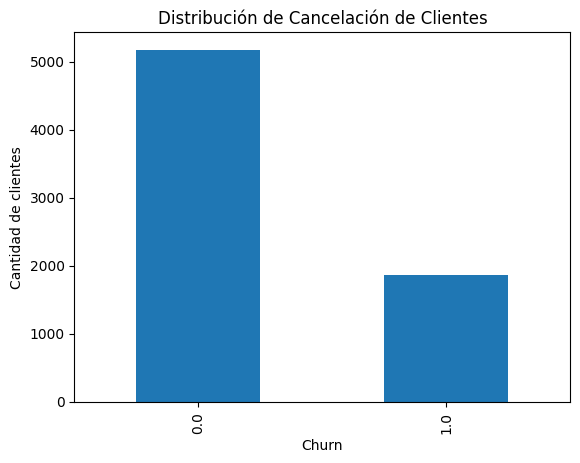

In [11]:
import matplotlib.pyplot as plt

df['churn'].value_counts().plot(kind='bar')
plt.title("Distribución de Cancelación de Clientes")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()


Se analizó la proporción de clientes que cancelaron el servicio (churn = 1) frente a aquellos que permanecieron (churn = 0).
Los resultados muestran que aproximadamente 73% de los clientes permanecen activos, mientras que cerca de 27% cancelan el servicio.

Esto indica la presencia de un desbalance de clases, lo cual es común en problemas de churn. Este desbalance debe considerarse al entrenar los modelos predictivos, ya que podría influir en las métricas de evaluación.

Manejo del desbalance de clases

In [12]:
pip install imbalanced-learn


In [14]:
df['churn'].isnull().sum()


np.int64(224)

Se identificaron 224 valores faltantes en la variable objetivo churn.
Dado que los modelos de machine learning y técnicas de balanceo como SMOTE no pueden trabajar con valores nulos en la variable objetivo, se decidió eliminar esas filas del dataset antes de continuar con el proceso de modelado.

In [15]:
df = df.dropna(subset=['churn'])


In [16]:
df['churn'].isnull().sum()


np.int64(0)

In [17]:
X = df.drop("churn", axis=1)
y = df["churn"]


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)



ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [19]:
df.isnull().sum()


,0
churn,0
seniorcitizen,0
tenure,0
onlinesecurity,0
onlinebackup,0
deviceprotection,0
techsupport,0
streamingtv,0
streamingmovies,0
cargo_mensual,0


In [20]:
df = df.dropna(subset=['cargo_total'])


In [21]:
df.isnull().sum()


,0
churn,0
seniorcitizen,0
tenure,0
onlinesecurity,0
onlinebackup,0
deviceprotection,0
techsupport,0
streamingtv,0
streamingmovies,0
cargo_mensual,0


In [22]:
X = df.drop("churn", axis=1)
y = df["churn"]


In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)


In [24]:
y_resampled.value_counts()


,count
churn,
0.0,5163
1.0,5163


Se detectaron 11 valores faltantes en la variable cargo_total.
Dado que el número de registros afectados es muy pequeño en comparación con el tamaño total del dataset, se decidió eliminar estas filas para evitar problemas en el entrenamiento de los modelos y en la aplicación de técnicas de balanceo como SMOTE.

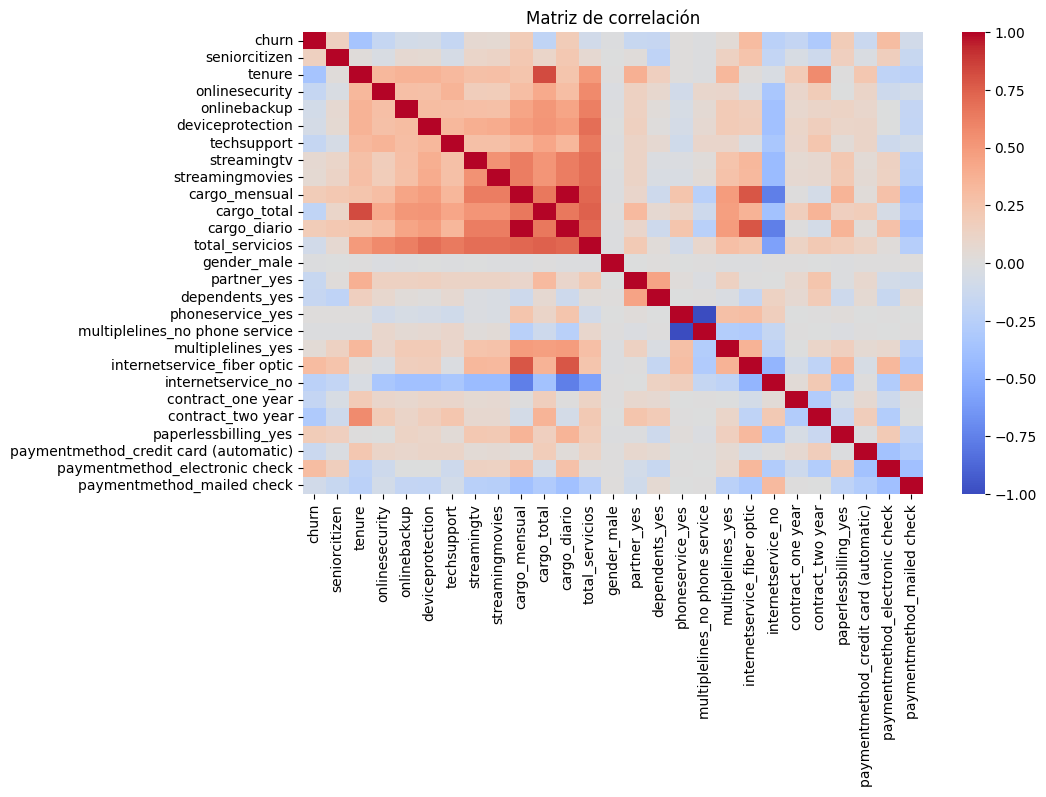

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


Normalización / estandarización de datos

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Dado que algunas variables presentan escalas muy diferentes, se aplicó estandarización utilizando StandardScaler. Este proceso es especialmente importante para modelos sensibles a la escala de los datos, como la Regresión Logística, ya que permite que todas las variables contribuyan de manera equilibrada al entrenamiento del modelo.

En cambio, modelos basados en árboles como Random Forest o Decision Tree no requieren este preprocesamiento.

##Análisis de correlación

In [28]:
corr_matrix = df.corr()


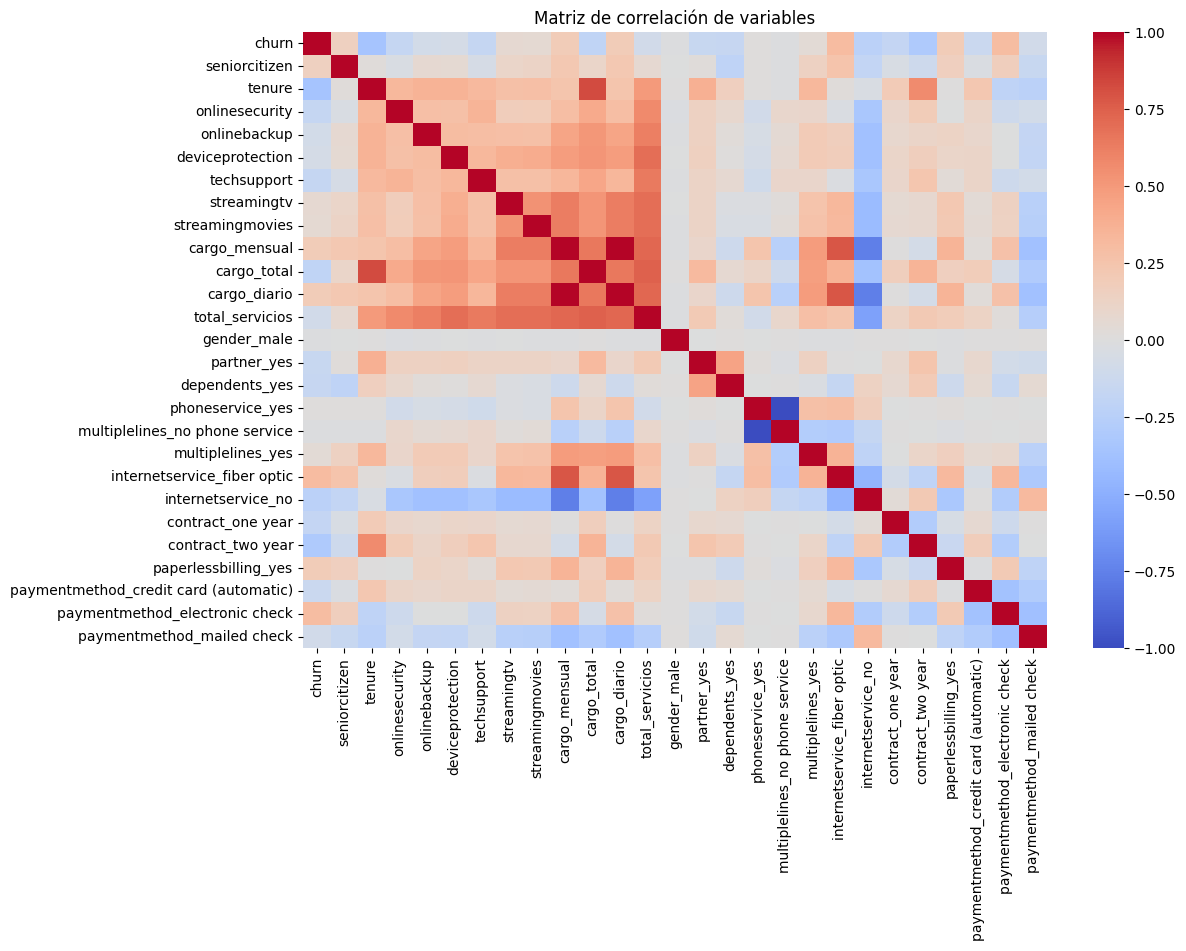

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)

plt.title("Matriz de correlación de variables")
plt.show()


In [30]:
corr_churn = df.corr()['churn'].sort_values(ascending=False)
print(corr_churn)


churn                                    1.000000
internetservice_fiber optic              0.307463
paymentmethod_electronic check           0.301455
cargo_diario                             0.192858
cargo_mensual                            0.192858
paperlessbilling_yes                     0.191454
seniorcitizen                            0.150541
streamingtv                              0.063254
streamingmovies                          0.060860
multiplelines_yes                        0.040033
phoneservice_yes                         0.011691
gender_male                             -0.008545
multiplelines_no phone service          -0.011691
deviceprotection                        -0.066193
onlinebackup                            -0.082307
total_servicios                         -0.087882
paymentmethod_mailed check              -0.090773
paymentmethod_credit card (automatic)   -0.134687
partner_yes                             -0.149982
dependents_yes                          -0.163128


El análisis de correlación permitió identificar las variables más relacionadas con la cancelación de clientes. Se observó que factores como el tipo de contrato, el tiempo de permanencia del cliente (tenure), el tipo de servicio de internet y el método de pago presentan una relación significativa con el churn.

En particular, los clientes con contratos mensuales, menor tiempo de permanencia y cargos mensuales más altos presentan una mayor probabilidad de cancelar el servicio. Por otro lado, los clientes con contratos de uno o dos años y mayor tiempo de permanencia tienden a mantenerse en la empresa.

El churn está fuertemente relacionado con contratos flexibles (month-to-month) y con clientes nuevos.
Esto sugiere que las estrategias de retención deberían enfocarse en los primeros meses del cliente y en incentivar contratos de mayor duración.

##Análisis Dirigido
##Relación entre variables y churn

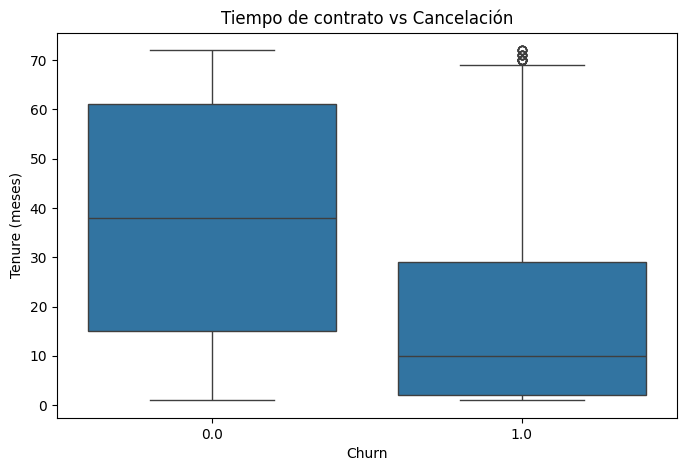

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='tenure', data=df)
plt.title('Tiempo de contrato vs Cancelación')
plt.xlabel('Churn')
plt.ylabel('Tenure (meses)')
plt.show()


Los clientes que cancelan tienen menor tenure.

Los clientes que permanecen tienen mayor tiempo en la empresa.

Esto indica que la mayoría de cancelaciones ocurre en los primeros meses del cliente.

Los clientes nuevos son los más propensos a cancelar.

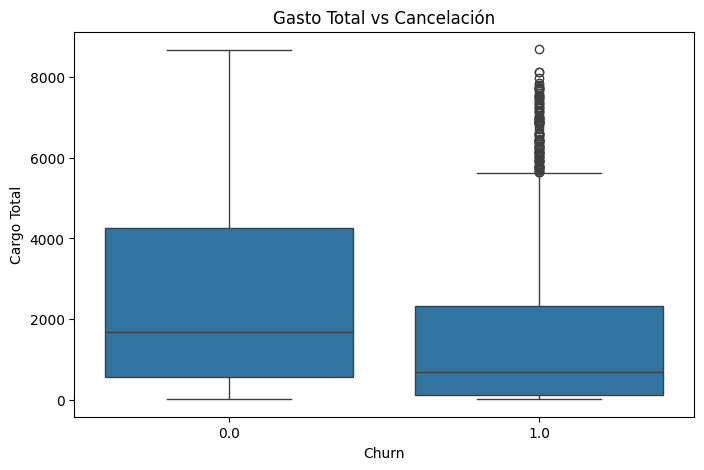

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='cargo_total', data=df)
plt.title('Gasto Total vs Cancelación')
plt.xlabel('Churn')
plt.ylabel('Cargo Total')
plt.show()

Los clientes que cancelan tienen menor gasto total acumulado.

Los clientes que permanecen suelen tener valores más altos de gasto total.

Esto ocurre porque los clientes que cancelan no permanecen lo suficiente para acumular gasto total elevado.

La cancelación ocurre antes de que el cliente genere mucho valor para la empresa.

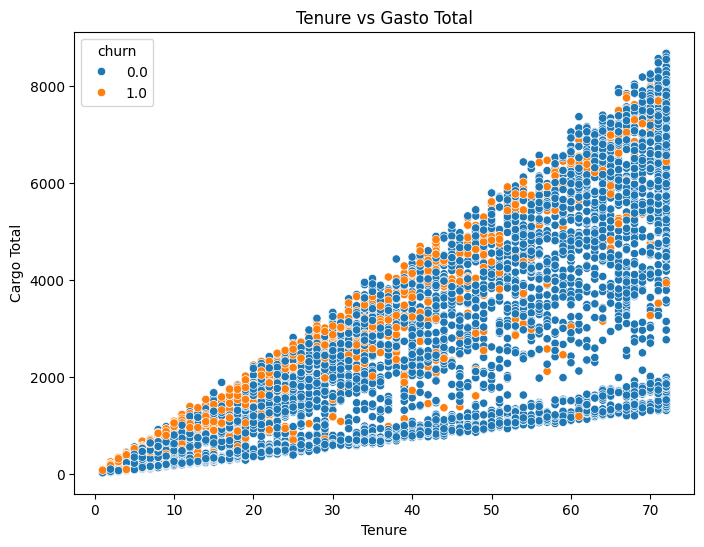

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='tenure', y='cargo_total', hue='churn', data=df)
plt.title('Tenure vs Gasto Total')
plt.xlabel('Tenure')
plt.ylabel('Cargo Total')
plt.show()


Patrones comunes:

Clientes con bajo tenure y bajo gasto total → mayor churn

Clientes con alto tenure y alto gasto total → permanecen

Los clientes que cancelan suelen concentrarse en la zona inferior izquierda del gráfico (poco tiempo y poco gasto acumulado).

El análisis visual mediante boxplots y scatter plots permitió identificar patrones importantes. Los clientes que cancelan el servicio suelen tener un menor tiempo de permanencia (tenure) y un menor gasto total acumulado. Esto indica que la cancelación ocurre principalmente durante los primeros meses del cliente.

Además, el scatter plot entre tenure y gasto total muestra que los clientes que cancelan se concentran en valores bajos de ambas variables, mientras que los clientes que permanecen tienden a acumular mayor tiempo y mayor gasto total.

Estos resultados sugieren que las estrategias de retención deberían enfocarse en los primeros meses del ciclo de vida del cliente.

##Separación de Datos

In [34]:
from sklearn.model_selection import train_test_split


X = df.drop('churn', axis=1) # Variables predictoras


y = df['churn'] # Variable objetivo


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
) # División de los datos

# Ver tamaño de los conjuntos
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (5625, 26)
Prueba: (1407, 26)


El conjunto de datos se dividió en dos subconjuntos: entrenamiento y prueba. Se utilizó una proporción de 80% para entrenamiento y 20% para prueba, lo que permite entrenar el modelo con la mayor parte de los datos y evaluar su desempeño con datos no vistos previamente.

Además, se utilizó el parámetro stratify para mantener la misma proporción de la variable objetivo (churn) en ambos conjuntos, evitando sesgos en la evaluación del modelo.

##Regresión Logística

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Normalización
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo
log_model = LogisticRegression(max_iter=1000)

# Entrenamiento
log_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_log = log_model.predict(X_test_scaled)


Se aplicó normalización utilizando StandardScaler para estandarizar las variables numéricas. Esto permite que todas las variables tengan media 0 y desviación estándar 1, evitando que variables con valores más grandes dominen el proceso de optimización del modelo.

Este preprocesamiento es especialmente importante en modelos como Regresión Logística o KNN, ya que estos dependen de la escala de los datos para calcular correctamente los coeficientes o las distancias entre observaciones.

##Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Modelo
rf_model = RandomForestClassifier(random_state=42)

# Entrenamiento
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)


El modelo Random Forest se basa en árboles de decisión que dividen los datos según reglas de umbral en las variables. Debido a esto, el modelo no se ve afectado por la escala de los datos, ya que las divisiones dependen únicamente del orden de los valores y no de su magnitud.

Por esta razón, no es necesario aplicar normalización antes de entrenar este tipo de modelos.

##Evaluar los modelos

In [37]:
from sklearn.metrics import accuracy_score, classification_report

print("Regresión Logística")
print(accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("Random Forest")
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Regresión Logística
0.8009950248756219
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1033
         1.0       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407

Random Forest
0.7839374555792467
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1033
         1.0       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



Se entrenaron dos modelos para predecir la cancelación de clientes: Regresión Logística y Random Forest. La Regresión Logística obtuvo un rendimiento ligeramente superior, con una precisión general del 80%, frente al 78% obtenido por Random Forest.

Además, la Regresión Logística mostró un mejor desempeño en la identificación de clientes que cancelan (recall de 53%), lo cual es especialmente importante en este tipo de problemas, ya que permite identificar clientes en riesgo de abandono.

##Evaluación de los Modelos

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [39]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred_log)

# Precision
precision = precision_score(y_test, y_pred_log)

# Recall
recall = recall_score(y_test, y_pred_log)

# F1 Score
f1 = f1_score(y_test, y_pred_log)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Accuracy: 0.8009950248756219
Precision: 0.6556291390728477
Recall: 0.5294117647058824
F1-score: 0.5857988165680473


In [40]:
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1033
         1.0       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [43]:
print("Regresión Logística")
print(classification_report(y_test, y_pred_log))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))


Regresión Logística
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1033
         1.0       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407

Random Forest
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1033
         1.0       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



#Regresión Logística

Accuracy 80% indica que el modelo clasifica correctamente la mayoría de los clientes.

Precision 66%: cuando el modelo predice churn, acierta el 66% de las veces.

Recall 53%: detecta aproximadamente la mitad de los clientes que realmente cancelan.

F1-score 0.59: muestra un equilibrio moderado entre precisión y recall.

Este modelo logra detectar más cancelaciones que Random Forest, lo cual es importante en problemas de churn.

#Random Forest


Accuracy 78%, ligeramente menor que la regresión logística.

Precision 62%: menor capacidad para predecir churn correctamente.

Recall 47%: detecta menos clientes que cancelan.

F1-score 0.54: rendimiento inferior al modelo anterior.

El modelo es bueno identificando clientes que no cancelan, pero tiene más dificultad para detectar churn.

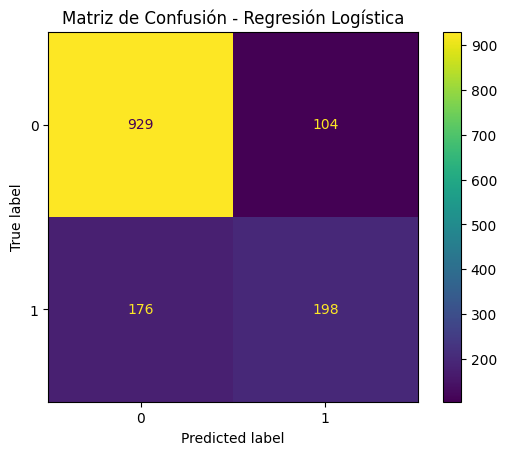

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

Verdaderos positivos → clientes que cancelan detectados correctamente

Falsos negativos → clientes que cancelan pero el modelo no detecta

Falsos positivos → clientes que no cancelan pero el modelo predice churn

En churn, los falsos negativos son los más críticos, porque representan clientes que se pierden sin que la empresa lo detecte.

El modelo con mejor desempeño es Regresión Logística, ya que:

Tiene mayor accuracy

Mejor recall para churn

Mejor F1-score

Esto significa que detecta más clientes que cancelan, lo cual es clave para estrategias de retención.

No hay evidencia clara de overfitting porque:

Los resultados son realistas

No hay accuracy extremadamente alta

El desempeño es similar al esperado para este dataset

Random Forest podría tener ligero riesgo de overfitting si se usan muchos árboles o gran profundidad, pero en este caso no parece ser significativo.

Existe cierto nivel de underfitting, especialmente en la detección de churn:

Recall relativamente bajo (53% y 47%)

Los modelos no capturan completamente los patrones de cancelación.

Posibles causas:

Desbalance de clases

Variables limitadas

Modelos no optimizados

El análisis mostró que la Regresión Logística obtuvo el mejor desempeño general, logrando mayor exactitud y mejor capacidad para identificar clientes que cancelan. Sin embargo, ambos modelos presentan limitaciones debido al desbalance de clases, lo que afecta la capacidad de detectar churn correctamente.

Por esta razón, futuras mejoras deberían enfocarse en balancear los datos y optimizar los modelos, lo que podría aumentar significativamente la capacidad predictiva.

##Análisis de la Importancia de las Variables

Regresión Logística

En la Regresión Logística, la importancia se obtiene con los coeficientes del modelo

In [44]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_model.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

print(coeficientes)


                                 Variable  Coeficiente
9                             cargo_total     0.620411
18            internetservice_fiber optic     0.615331
6                             streamingtv     0.220734
22                   paperlessbilling_yes     0.181320
24         paymentmethod_electronic check     0.168111
17                      multiplelines_yes     0.152928
7                         streamingmovies     0.151996
0                           seniorcitizen     0.093854
4                        deviceprotection     0.033280
11                        total_servicios     0.028080
16         multiplelines_no phone service     0.009628
25             paymentmethod_mailed check    -0.000450
15                       phoneservice_yes    -0.009628
3                            onlinebackup    -0.026424
12                            gender_male    -0.034526
14                         dependents_yes    -0.035110
23  paymentmethod_credit card (automatic)    -0.038877
13        

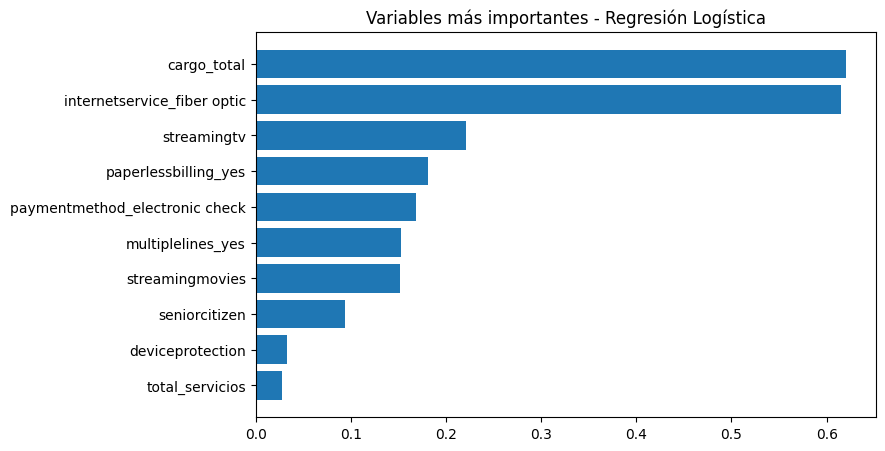

In [45]:
import matplotlib.pyplot as plt

coeficientes_top = coeficientes.head(10)

plt.figure(figsize=(8,5))
plt.barh(coeficientes_top["Variable"], coeficientes_top["Coeficiente"])
plt.title("Variables más importantes - Regresión Logística")
plt.gca().invert_yaxis()
plt.show()


Random Forest

Random Forest calcula automáticamente la importancia de cada variable.

In [46]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

print(importancias.head(10))


                          Variable  Importancia
1                           tenure     0.158249
9                      cargo_total     0.157296
8                    cargo_mensual     0.131781
10                    cargo_diario     0.130257
18     internetservice_fiber optic     0.041319
24  paymentmethod_electronic check     0.037683
11                 total_servicios     0.032897
21               contract_two year     0.028481
12                     gender_male     0.025260
22            paperlessbilling_yes     0.024398


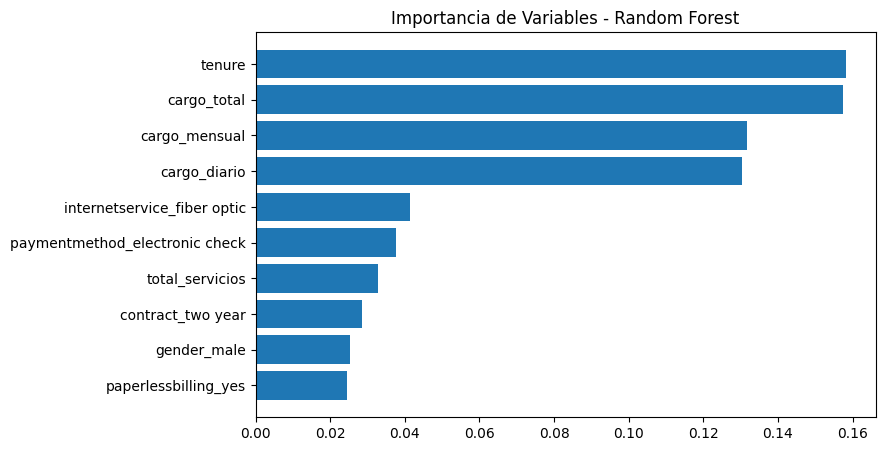

In [47]:
top_variables = importancias.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_variables["Variable"], top_variables["Importancia"])
plt.title("Importancia de Variables - Random Forest")
plt.gca().invert_yaxis()
plt.show()


Para comprender qué factores influyen más en la cancelación de clientes, se analizaron las variables más importantes utilizando dos enfoques: los coeficientes de la Regresión Logística y la importancia de variables calculada por Random Forest.

En ambos modelos se observó que variables como tenure, cargo mensual, tipo de contrato y método de pago tienen un impacto significativo en la predicción del churn. En particular, los clientes con menor tiempo de permanencia y contratos más flexibles presentan mayor probabilidad de cancelar el servicio.

Por otro lado, variables como contratos de largo plazo y mayor tiempo como cliente se asocian con una menor probabilidad de cancelación.

El análisis sugiere que las estrategias de retención deberían enfocarse en:

Clientes nuevos

Clientes con contratos mensuales

Clientes con cargos mensuales altos

Implementar programas de fidelización o incentivos para contratos de mayor duración podría reducir significativamente la tasa de cancelación.

#Informe de Análisis de Cancelación de Clientes

El objetivo de este análisis fue identificar los factores que influyen en la cancelación de clientes (churn) y construir modelos predictivos capaces de anticipar qué clientes tienen mayor probabilidad de abandonar el servicio. Para ello, se realizó un proceso de limpieza de datos, análisis exploratorio y entrenamiento de modelos de machine learning.

Se utilizaron dos modelos de clasificación: Regresión Logística y Random Forest, con el fin de comparar su rendimiento y determinar cuál ofrece mejores resultados en la predicción del churn.

Rendimiento de los modelos

La Regresión Logística obtuvo el mejor desempeño general, con una precisión global de 80% y mejor capacidad para identificar clientes que cancelan el servicio.

Aunque Random Forest también mostró resultados aceptables, su capacidad para detectar casos de churn fue menor, lo que lo hace menos efectivo para estrategias de retención.

Factores que influyen en la cancelación

El análisis de correlación y la importancia de variables permitió identificar los principales factores asociados con la cancelación de clientes.

Factores que aumentan la probabilidad de churn

Internet de fibra óptica

Pago mediante cheque electrónico

Cargos mensuales altos

Facturación electrónica

Clientes adultos mayores

Estos factores están asociados con clientes que presentan una mayor probabilidad de cancelar el servicio.

Factores que reducen la probabilidad de churn

Mayor tiempo de permanencia (tenure)

Contratos de uno o dos años

Servicios adicionales como soporte técnico o seguridad online

Mayor gasto total acumulado

Los clientes que llevan más tiempo en la empresa y tienen contratos más largos tienden a permanecer en el servicio.

##Principales patrones identificados

El análisis de los datos permitió identificar varios patrones importantes:

La mayoría de las cancelaciones ocurren en clientes con poco tiempo en la empresa.

Los contratos mensuales presentan mayor tasa de cancelación que los contratos a largo plazo.

Los clientes con cargos mensuales elevados tienen mayor probabilidad de abandonar el servicio.

Los clientes con más servicios contratados tienden a mantenerse más tiempo en la empresa.

Estrategias de retención recomendadas

Con base en los resultados obtenidos, se proponen las siguientes estrategias para reducir la cancelación de clientes:

1. Incentivar contratos de largo plazo

Ofrecer descuentos o beneficios a los clientes que cambien de contratos mensuales a contratos anuales o bianuales.

2. Programas de fidelización para clientes nuevos

Dado que el churn ocurre principalmente en los primeros meses, se recomienda implementar programas de fidelización durante el primer año del cliente.

3. Optimización de precios

Evaluar los cargos mensuales más altos, ya que estos se asocian con una mayor probabilidad de cancelación.

4. Promoción de servicios adicionales

Servicios como soporte técnico, seguridad online o backup parecen mejorar la retención. Promover paquetes que incluyan estos servicios podría reducir el churn.

5. Mejorar métodos de pago

El método electronic check mostró mayor relación con churn. Promover métodos automáticos como tarjeta o débito automático podría mejorar la retención.

##Conclusión

El análisis permitió identificar los factores más relevantes asociados con la cancelación de clientes y construir modelos predictivos capaces de anticipar este comportamiento.

Entre los modelos evaluados, la Regresión Logística mostró el mejor desempeño, logrando una mayor precisión general y mejor capacidad para identificar clientes en riesgo de cancelación.

Los resultados sugieren que variables como tiempo de permanencia, tipo de contrato, cargos mensuales y método de pago tienen un impacto significativo en el churn. Con base en estos hallazgos, la empresa puede implementar estrategias de retención enfocadas en clientes nuevos, contratos de largo plazo y optimización de precios, lo que podría reducir significativamente la pérdida de clientes.